# Explainability Plots

In [1]:
import warnings
import joblib
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, confusion_matrix, roc_auc_score

from pathlib import Path
import shutil
import sys 
sys.path.append('..')  

from module.dataload import DPN_data
import ymlconfig

%matplotlib inline
%load_ext autoreload
%autoreload 2

warnings.filterwarnings('ignore')
np.set_printoptions(precision=3)  # decimal places for outputs from numpy
pd.set_option("display.precision", 3)  # decimal places for outputs from pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

## Load / Reload Selection Utility Functions

In [2]:
from utils2 import explainability as exp

----

## Read Config File

In [3]:
config_path = Path(r'experiments')
config_filename =  "bin_exp_final.yml"
config_dict = ymlconfig.load_config(config_path / config_filename)
config = ymlconfig.dict_to_namespace(config_dict)
config_dict


{'experiment': {'summary': 'binary classification - Explainability Analysis (development)',
  'classification_type': 'binary',
  'stage': 'explainability',
  'tag': 'final',
  'verbosity': 1,
  'random_seed': 42},
 'data': {'dataset_path': '../dataset/Sudoscan Working File with Stats.xlsx'},
 'model': {'code': 'catboost', 'name': 'CatBoost'},
 'param_space': {'iterations': {'min': 100, 'max': 500},
  'depth': {'min': 4, 'max': 10},
  'learning_rate': {'min': 0.01, 'max': 0.1},
  'l2_leaf_reg': {'min': 1, 'max': 9}},
 'hpo_results': {'file': 'binary\\hyperparameter_optimization\\CatBoost\\final\\optimization_results.json',
  'threshold': 0.6352084424142594},
 'optimization': {'scoring': 'roc_auc',
  'k_splits_outer': 3,
  'k_splits_inner': 3,
  'n_iter': 5}}

#### Set output directory

In [4]:
outputdir = config_path /  config.experiment.classification_type /  config.experiment.stage / config.model.code / config.experiment.tag 
outputdir.mkdir(parents=True, exist_ok=True)
print(outputdir)

experiments\binary\explainability\catboost\final


#### Copy config file to output directory

In [5]:
source = config_path / config_filename
destination = outputdir / config_filename
shutil.copy(source, destination)

WindowsPath('experiments/binary/explainability/catboost/final/bin_exp_final.yml')

#### Verify Threshold Value

In [6]:
hpo_results_file = config.hpo_results.file
with open(config_path / hpo_results_file) as f:
    hpo_results = json.load(f)
assert np.isclose(hpo_results['threshold_mean'], config.hpo_results.threshold)

## Data Loading

In [7]:
D = DPN_data(config.data.dataset_path)
D.load(classification=config.experiment.classification_type)

dfdpn = D.df
data_cols = dfdpn.drop(D.non_data_cols, axis=1, errors="ignore").columns
X = dfdpn[data_cols]
y = dfdpn['Confirmed_Binary_DPN']
X.shape, y.shape

((190, 40), (190,))

## k-fold Optimization

In [8]:
split_results =  exp.get_ksplit_trained_models(X, y, config)


[[20  0]
 [ 4 40]]
youden:  0.9090909090909092
roc_auc:  0.9829545454545455

[[15  5]
 [ 1 42]]
youden:  0.7267441860465116
roc_auc:  0.986046511627907

[[18  2]
 [ 5 38]]
youden:  0.7837209302325583
roc_auc:  0.9441860465116279


In [9]:
df_ksm = pd.DataFrame([{k: result[k] for k in ["youden", "roc_auc"]} for result in split_results]).T
df_ksm['mean'] = df_ksm.mean(axis=1)
df_ksm['std'] = df_ksm.std(axis=1)
df_ksm

,0,1,2,mean,std
youden,0.909,0.727,0.784,0.807,0.076
roc_auc,0.983,0.986,0.944,0.971,0.019


### Save model results

In [10]:
joblib.dump(split_results, outputdir / f"{config.model.code}_ksplit_trained_models.joblib")
df_ksm.to_csv(outputdir / f"{config.model.code}_ksplit_trained_models_result_summary.csv")

## Analysis Plots

In [12]:
split_results = joblib.load(outputdir / f"{config.model.code}_ksplit_trained_models.joblib")

### Feature Importance

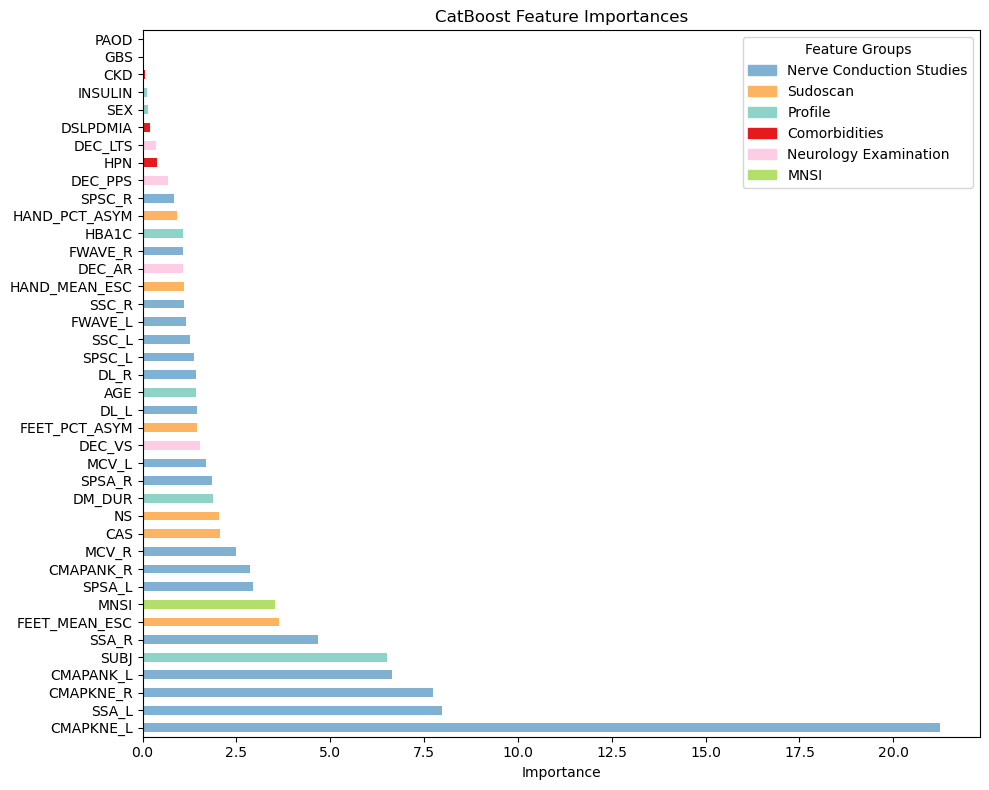

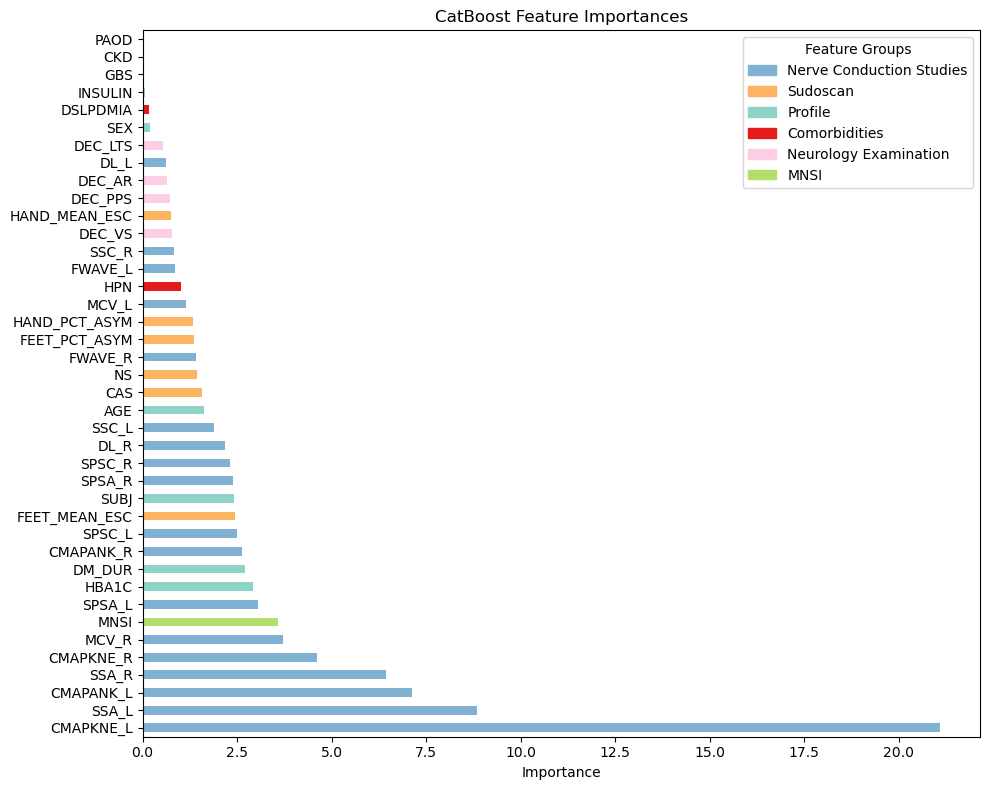

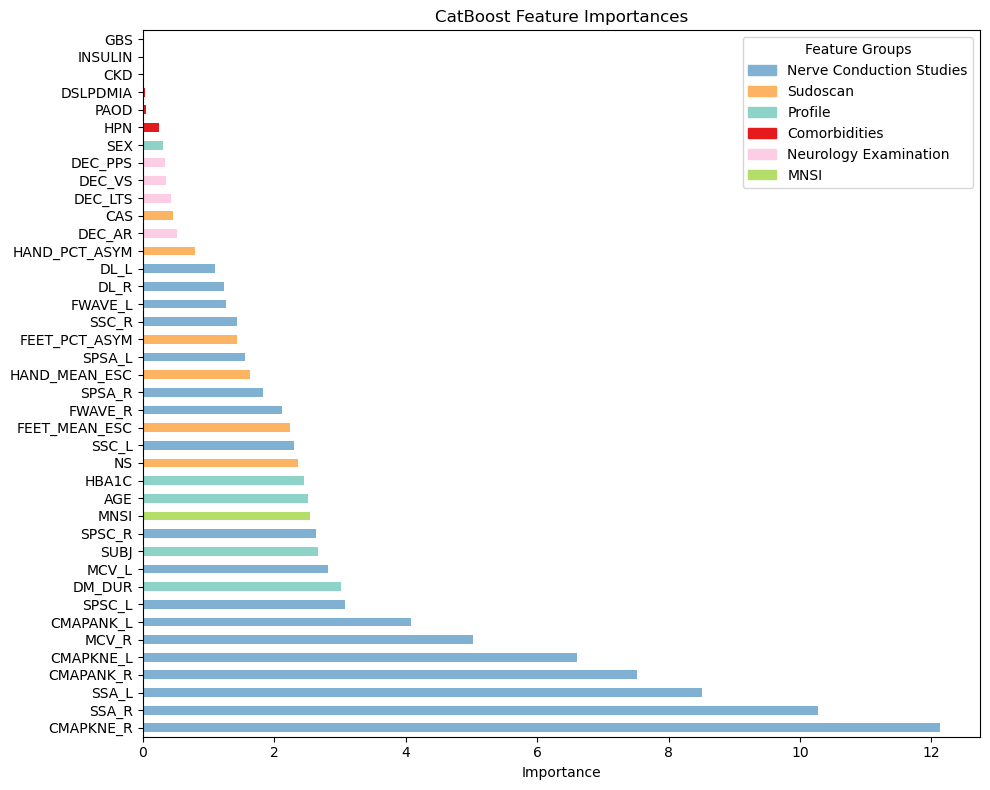

In [13]:
for s in range(len(split_results)): 
    model = split_results[s]['model']
    feature_names = X.columns
    exp.plot_importances(D, model, s, feature_names, config, 
                        minimum=None, limit=None, 
                        savedir=outputdir)    

#### ROC Curve

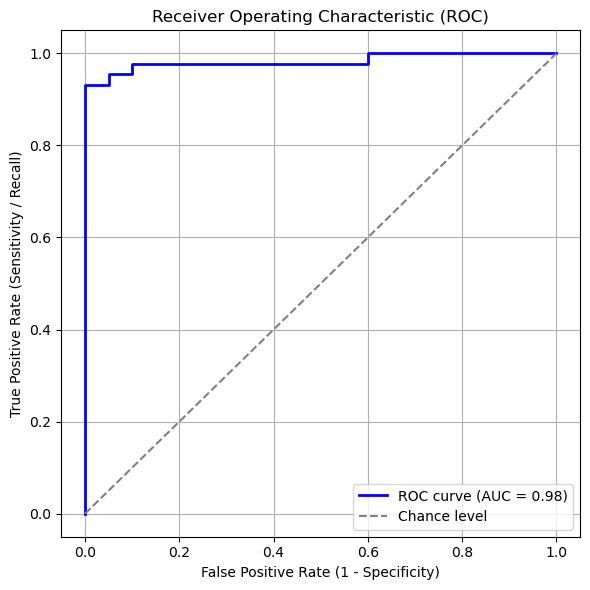

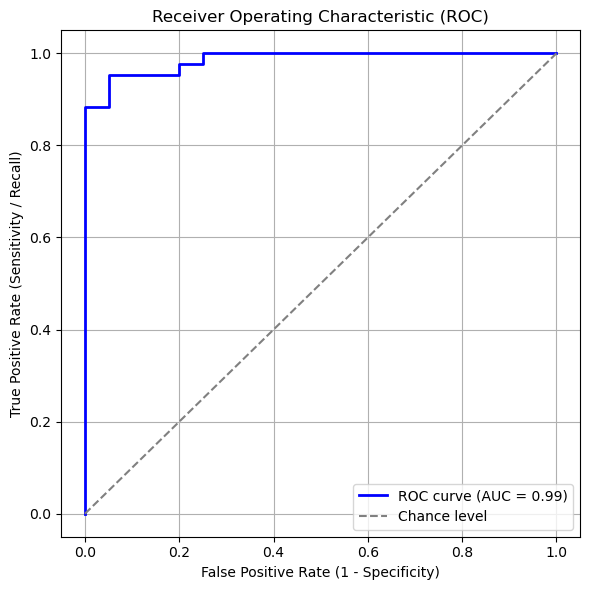

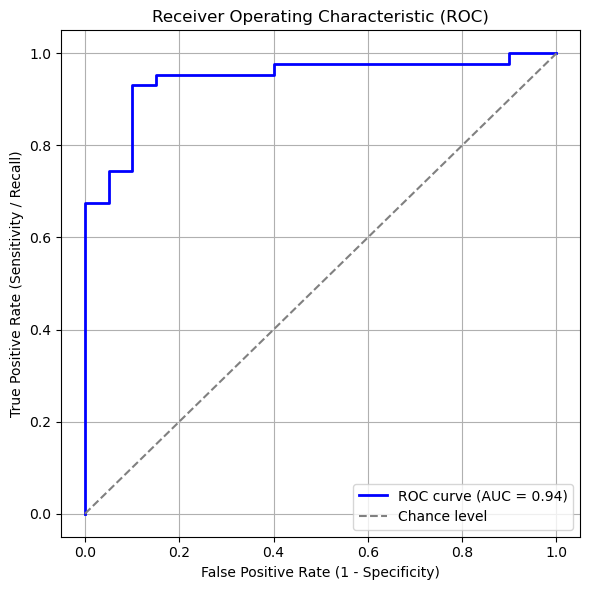

In [14]:
for s in range(len(split_results)): 
    model = split_results[s]['model']
    X_test = split_results[s]['X_test']
    y_test = split_results[s]['y_test']
    y_proba = model.predict_proba(X_test)[:,1]
    exp.plot_roc_auc(y_test, y_proba, s, config, outputdir);    


### DCA

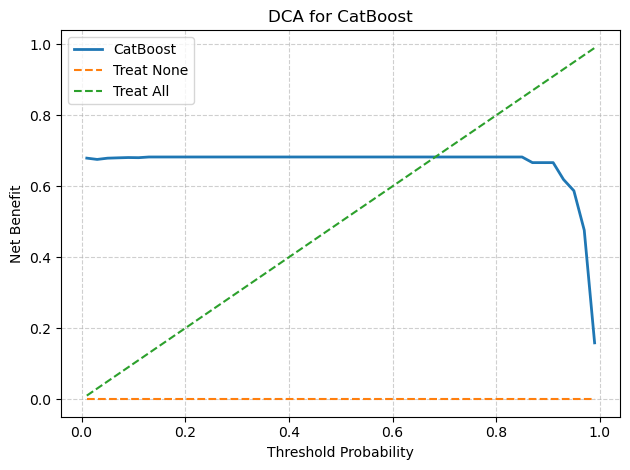

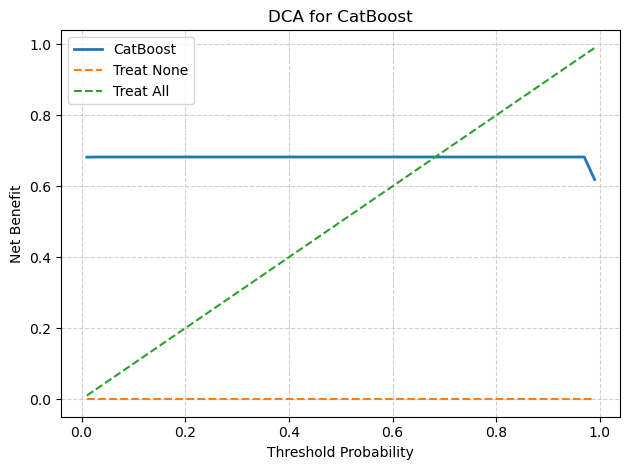

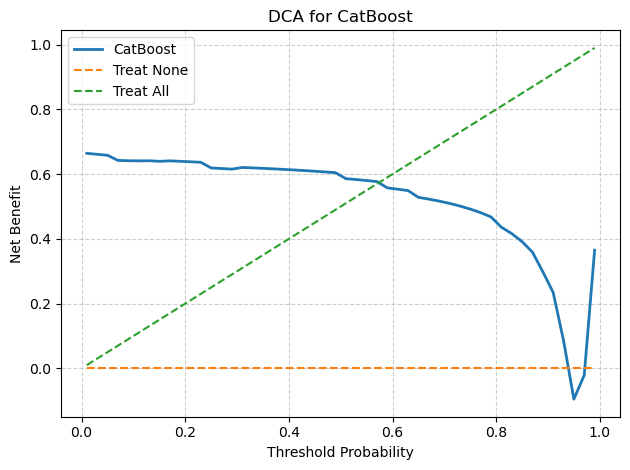

In [15]:
for s in range(len(split_results)): 
    model = split_results[s]['model']
    thresholds, nb = exp.plot_decision_curve_analysis(model, s, X_test, y_test, config, savedir=outputdir)

## SHAP Analysis

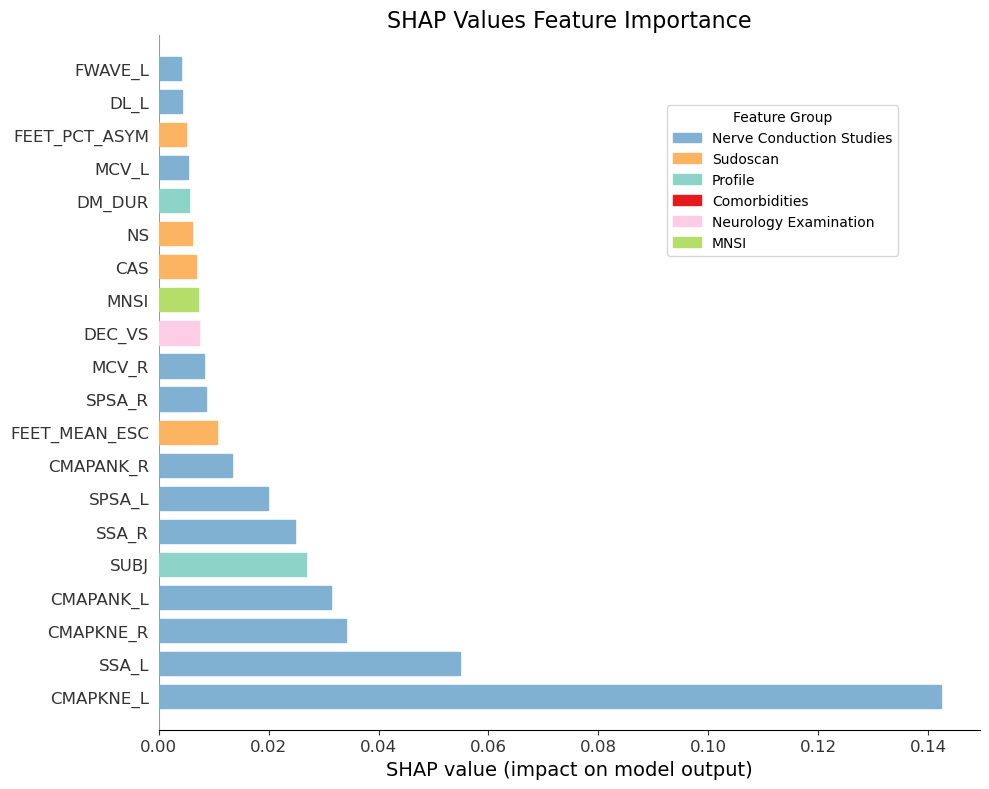

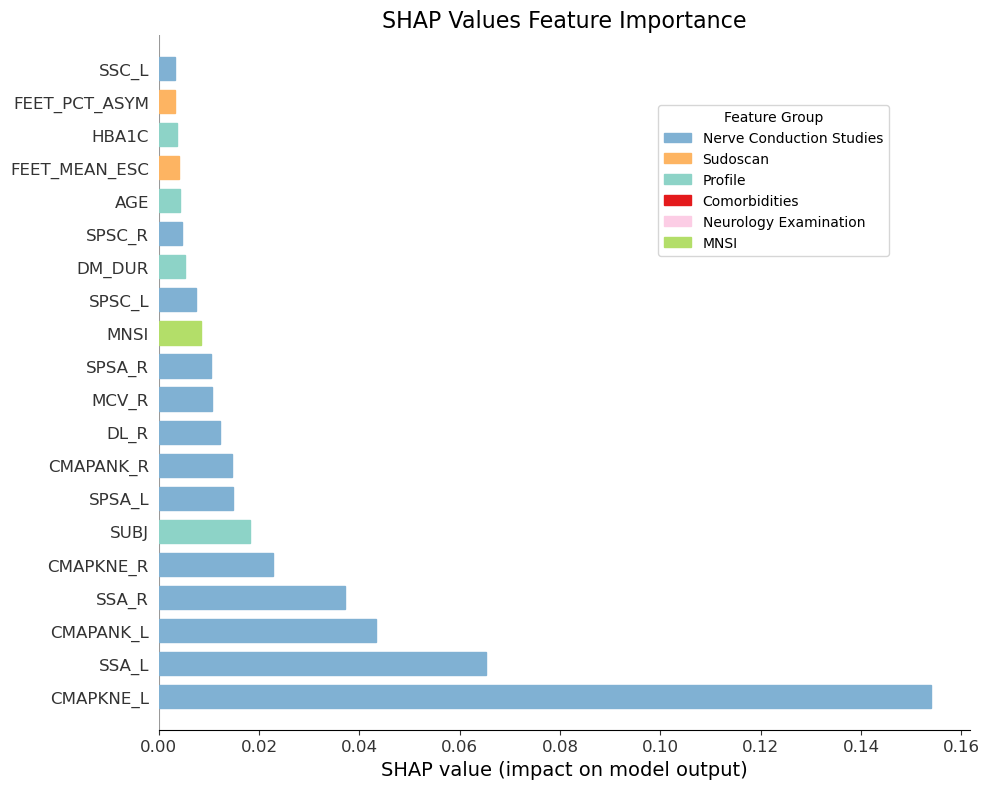

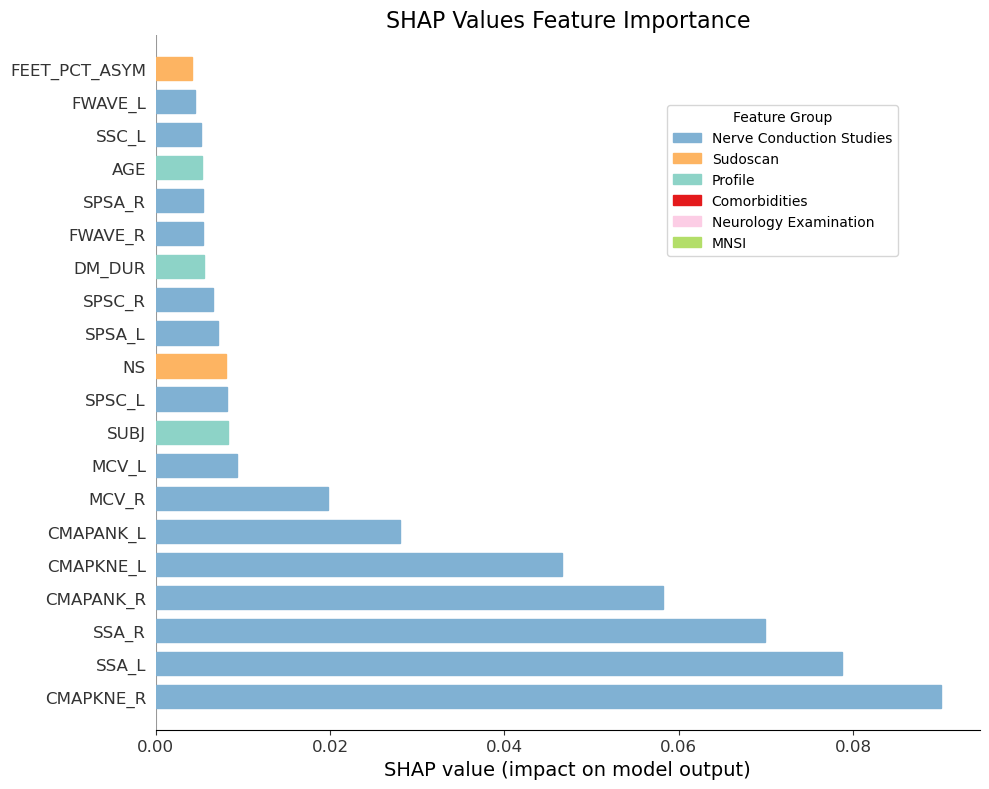

In [16]:
for s in range(len(split_results)): 
    model = split_results[s]['model']
    exp.plot_shap(D, model, s, config, X_test, savedir=outputdir)

## Global Counterfactual Analysis

### Actionable (Flip Both Ways), Full dataset

#### Preparation

In [ ]:
X.shape, y.shape

In [ ]:
dfXy = pd.concat([X, y], axis=1)
dfXy.shape

In [ ]:
d = dice_ml.Data(dataframe=dfXy, continuous_features=dfXy.columns.drop('Confirmed_Binary_DPN').tolist(), outcome_name='Confirmed_Binary_DPN')
m = dice_ml.Model(model=optimized_model, backend="sklearn", model_type="classifier")
exp = dice_ml.Dice(d, m, method="genetic")

#### Generate 3 Sample CFs for Patient 0

In [ ]:
pid = 0
query_instance = X[pid:pid+1]
print(f"generating counterfactuals for the {model_name} model")    
e1 = exp.generate_counterfactuals(
    query_instance, total_CFs=3, desired_class="opposite")    
e1.visualize_as_dataframe(show_only_changes=True) 


#### Global Importance

In [ ]:
cobj = exp.global_feature_importance(X, total_CFs=10, posthoc_sparsity_param=None)
print(cobj.summary_importance)

In [ ]:
df_imp = pd.DataFrame([cobj.summary_importance])
df_imp

In [ ]:
s = df_imp.iloc[0]
s = s[s>0]

fig, ax = plt.subplots(figsize=(10, 8))
s.plot.barh(ax=ax)
ax.set_title("Global Importance")
ax.set_ylabel("Category")
ax.set_xlabel("Value")
plt.tight_layout()
plt.savefig('outputs/figures/rf_cf_global.png')
plt.show()


In [ ]:
df_imp.to_csv(r'outputs\counterfactuals\rf_global.csv')

#### Load Global Feature Importance from File

In [ ]:
df_imp = pd.read_csv(r'outputs\counterfactuals\rf_global.csv')
df_imp

In [ ]:
blue_hex_colors = [
    '#ADD8E6', # Light Blue
    '#87CEEB', # Sky Blue
    '#6495ED', # Cornflower Blue
    '#4682B4', # Steel Blue
    '#1E90FF', # Dodger Blue
    '#0000CD', # Medium Blue
    '#00008B', # Dark Blue
    '#000080'  # Navy
]

In [ ]:
s = df_imp.iloc[0]
s_trimmed = s[s>0]

feature_names = s_trimmed.index.to_list()
bar_colors = get_colors(feature_names) 

HIGHLIGHT_COLOR = '#0000CD'
ACTIONABLE_FEATURES = {'HBA1C', 'DSLPDMIA', 'INSULIN'} 

fig, ax = plt.subplots(figsize=(10, 8))
s_trimmed.plot.barh(ax=ax, color=bar_colors)

# Get all the y-axis tick labels
y_labels = ax.get_yticklabels()

# Loop through each label and check if it should be bold
for label in y_labels:
    feature_name = label.get_text() # Get the text of the label
    
    if feature_name in ACTIONABLE_FEATURES:
        # Set the font properties for bolding
        label.set_fontweight('bold')
        # Optional: Increase size for more emphasis
        # label.set_fontsize(11)
        label.set_color(HIGHLIGHT_COLOR) 

# Create Custom Legend Handles
legend_handles = [
    mpatches.Patch(color=color, label=label)
    for label, color in COLOR_GROUP_MAP.items()
]

# Add the Legend
ax.legend(
    handles=legend_handles,
    title="Feature Group",
    loc='upper right',
    bbox_to_anchor=(0.98, 0.98), # Place the legend outside the plot area
    borderaxespad=0.1
)

ax.set_title("Global Importance (Flip both ways)")
ax.set_ylabel("Category")
ax.set_xlabel("Value")
plt.tight_layout()
#plt.savefig('outputs/figures/rf_cf_global.png')
plt.show()



#### Local Feature Importance

In [ ]:
pid = 0
query_instance = X[pid:pid+1]
e1 = exp.generate_counterfactuals(query_instance, total_CFs=10, desired_class="opposite")    
# e1.visualize_as_dataframe(show_only_changes=True) 

In [ ]:
imp = exp.local_feature_importance(query_instance, cf_examples_list=e1.cf_examples_list)
df_imp = pd.DataFrame(imp.local_importance)
df_imp

In [ ]:
import matplotlib.pyplot as plt

s = df_imp.iloc[0]
s = s[s>0]

fig, ax = plt.subplots()
s.plot.bar(ax=ax)
ax.set_title("Bar chart of a pandas Series")
ax.set_xlabel("Category")
ax.set_ylabel("Value")
plt.tight_layout()
plt.show()

#### Necessity and Sufficiency of Instances

In [ ]:
import pandas as pd

def check_necessity_sufficiency(dice_exp, instance, all_features, desired_class="opposite", 
                                n_cf=10, seeds=[0,1,2,3,4], return_df=True):
    """
    Check necessity and sufficiency of features using DiCE.
    
    Parameters
    ----------
    dice_exp : dice_ml.Dice object
        Fitted DiCE explanation object.
    instance : dict or pd.DataFrame row
        The input instance to analyze.
    all_features : list
        List of feature names in the dataset.
    desired_class : str
        Target class for counterfactuals ("opposite" by default).
    n_cf : int
        Number of counterfactuals to request (for reliability).
    seeds : list
        Random seeds to try for sufficiency tests.
    return_df : bool
        If True, return pandas DataFrame. If False, return dict.
    
    Returns
    -------
    results : pd.DataFrame or dict
        Necessity and sufficiency results for each feature.
    """
    
    results = {}

    for f in tqdm(all_features):
        print(f)
        results[f] = {"necessary": False, "sufficient": False}

        # --- Necessity: vary only this feature ---
        cf_nec = dice_exp.generate_counterfactuals(
            instance,
            total_CFs=1,
            desired_class=desired_class,
            features_to_vary=[f]
        )
        if len(cf_nec.cf_examples_list[0].final_cfs_df) > 0:
            results[f]["necessary"] = True

        # --- Sufficiency: vary all features except this one ---
        features_without_f = [feat for feat in all_features if feat != f]
        
        found_cf = False
        for seed in seeds:
            cf_suff = dice_exp.generate_counterfactuals(
                instance,
                total_CFs=n_cf,
                desired_class=desired_class,
                features_to_vary=features_without_f,
                random_seed=seed
            )
            if len(cf_suff.cf_examples_list[0].final_cfs_df) > 0:
                found_cf = True
                break   # one valid CF is enough to say "not sufficient"
        
        if not found_cf:
            results[f]["sufficient"] = True

    if return_df:
        df_results = pd.DataFrame.from_dict(results, orient="index")
        df_results.index.name = "feature"
        return df_results
    else:
        return results


In [ ]:
pid = 0
query_instance = X[pid:pid+1]
all_features = list(X.columns)[:3]

In [ ]:
df_necsuf = check_necessity_sufficiency(
    exp, 
    query_instance, 
    all_features, 
    desired_class="opposite",
    n_cf=10,           # more CFs per trial
    seeds=[0,1,2,3,4][:1]  # multiple seeds
)
df_necsuf

### Progressive CF (Flip Negative to Positive)

In [ ]:
X[y==0].shape

In [ ]:
cobj = exp.global_feature_importance(X[y==0], total_CFs=10, posthoc_sparsity_param=None)
print(cobj.summary_importance)

In [ ]:
df_imp = pd.DataFrame([cobj.summary_importance])
df_imp

In [ ]:
s = df_imp.iloc[0]
s_trimmed = s[s>0]

feature_names = s_trimmed.index.to_list()
bar_colors = get_colors(feature_names) 

HIGHLIGHT_COLOR = '#0000CD'
PROGRESSIVE_FEATURES = {'DM_DUR', 'CKD', 'PAOD', 'HPN', 'GBS', 'AGE', 'DEC_VS', 'DEC_PPS', 'DEC_LTS', 'DEC_AR', 'MNSI'}

fig, ax = plt.subplots(figsize=(10, 8))
s_trimmed.plot.barh(ax=ax, color=bar_colors)

# Get all the y-axis tick labels
y_labels = ax.get_yticklabels()

# Loop through each label and check if it should be bold
for label in y_labels:
    feature_name = label.get_text() # Get the text of the label
    
    if feature_name in PROGRESSIVE_FEATURES:
        # Set the font properties for bolding
        label.set_fontweight('bold')
        # Optional: Increase size for more emphasis
        # label.set_fontsize(11)
        label.set_color(HIGHLIGHT_COLOR) 

# Create Custom Legend Handles
legend_handles = [
    mpatches.Patch(color=color, label=label)
    for label, color in COLOR_GROUP_MAP.items()
]

# Add the Legend
ax.legend(
    handles=legend_handles,
    title="Feature Group",
    loc='upper right',
    bbox_to_anchor=(0.98, 0.98), # Place the legend outside the plot area
    borderaxespad=0.1
)

ax.set_title("Global Importance (Negative to Positive)")
ax.set_ylabel("Category")
ax.set_xlabel("Value")
plt.tight_layout()
plt.savefig('outputs/figures/rf_cf_proressive_global.png')
plt.show()

### Hypothetical CF (Flip Positive to Negative)

In [ ]:
X[y==1].shape

In [ ]:
cobj = exp.global_feature_importance(X[y==1], total_CFs=10, posthoc_sparsity_param=None)
print(cobj.summary_importance)

In [ ]:
df_imp = pd.DataFrame([cobj.summary_importance])
df_imp

In [ ]:
s = df_imp.iloc[0]
s_trimmed = s[s>0]

feature_names = s_trimmed.index.to_list()
bar_colors = get_colors(feature_names) 

HIGHLIGHT_COLOR = '#0000CD'
PROGRESSIVE_FEATURES = {'DM_DUR', 'CKD', 'PAOD', 'HPN', 'GBS', 'AGE', 
                        'DEC_VS', 'DEC_PPS', 'DEC_LTS', 'DEC_AR', 'MNSI'}

fig, ax = plt.subplots(figsize=(10, 8))
s_trimmed.plot.barh(ax=ax, color=bar_colors)

# Get all the y-axis tick labels
y_labels = ax.get_yticklabels()

# Loop through each label and check if it should be bold
for label in y_labels:
    feature_name = label.get_text() # Get the text of the label
    
    if feature_name in PROGRESSIVE_FEATURES:
        # Set the font properties for bolding
        label.set_fontweight('bold')
        # Optional: Increase size for more emphasis
        # label.set_fontsize(11)
        label.set_color(HIGHLIGHT_COLOR) 

# Create Custom Legend Handles
legend_handles = [
    mpatches.Patch(color=color, label=label)
    for label, color in COLOR_GROUP_MAP.items()
]

# Add the Legend
ax.legend(
    handles=legend_handles,
    title="Feature Group",
    loc='upper right',
    bbox_to_anchor=(0.98, 0.98), # Place the legend outside the plot area
    borderaxespad=0.1
)

ax.set_title("Global Importance (Negative to Positive)")
ax.set_ylabel("Category")
ax.set_xlabel("Value")
plt.tight_layout()
plt.savefig('outputs/figures/rf_cf_proressive_global.png')
plt.show()

## Local Counterfactual Analysis

#### Preparation

In [ ]:
X.shape, y.shape

In [ ]:
dfXy = pd.concat([X, y], axis=1)
dfXy.shape

In [ ]:
d = dice_ml.Data(dataframe=dfXy, continuous_features=dfXy.columns.drop('Confirmed_Binary_DPN').tolist(), outcome_name='Confirmed_Binary_DPN')
m = dice_ml.Model(model=optimized_model, backend="sklearn", model_type="classifier")
exp = dice_ml.Dice(d, m, method="genetic")

#### Generate 3 Sample CFs for Patient 0

In [ ]:
pid = 0
query_instance = X[pid:pid+1]
print(f"generating counterfactuals for the {model_name} model")    
e1 = exp.generate_counterfactuals(
    query_instance, total_CFs=3, desired_class="opposite")    
e1.visualize_as_dataframe(show_only_changes=True) 


In [ ]:
optimized_model.fit(X_train, y_train)
y_pred = optimized_model.predict(X_val)
y_proba = best_model.predict_proba(X_val)[:, 1]


### Get logits

In [ ]:
# optimized_model.fit(X_train, y_train) # no longer needed
y_pred = optimized_model.predict(X_val)
y_proba = optimized_model.predict_proba(X_val)[:, 1]

In [ ]:
y_pred

In [ ]:
y_proba

In [ ]:
y_val

### Misclassified Local Counterfactuals

In [ ]:
y_pred==np.array(y_val)

In [ ]:
misclassified_indices = np.where(y_pred != np.array(y_val))[0]
misclassified_indices = misclassified_indices.tolist()
misclassified_indices

In [ ]:
y_val.iloc[misclassified_indices]

In [ ]:
y_proba[9]

In [ ]:
y_pred[misclassified_indices]

In [ ]:
pid=96
X[pid:pid+1]

#### Patient 41

In [ ]:
pid = 40 # dataframe is zero-indexed
query_instance = X[pid:pid+1]
print(f"Generating counterfactuals for Patient {pid+1}... ")    
e1 = exp.generate_counterfactuals(
    query_instance, total_CFs=30, desired_class="opposite")
#e1.visualize_as_dataframe(show_only_changes=True) 

### Borderline Local Counterfactuals

In [ ]:
margin = 0.05
borderline_indices = np.where((y_proba>(0.5-margin)) & (y_proba<(0.5+margin)))
borderline_indices

In [ ]:
y_val.iloc[borderline_indices]

In [ ]:
y_pred[borderline_indices]

#### Patient 41

In [ ]:
pid = 40 # dataframe is zero-indexed
query_instance = X[pid:pid+1]
print(f"Generating counterfactuals for Patient {pid+1}... ")    
e1 = exp.generate_counterfactuals(
    query_instance, total_CFs=30, desired_class="opposite")
#e1.visualize_as_dataframe(show_only_changes=True) 

 -----

## Raze Code

### DICT OF INITIAL MODELS

Logistic Regression Scaling

In [ ]:
logistic_regression = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('classifier', LogisticRegression())
])

In [ ]:
initial_models = {
    "dummy": DummyClassifier(),
    "random_forest": RandomForestClassifier(),
    "decision_tree": DecisionTreeClassifier(),
    "xgb": xgb.XGBClassifier(),
    "logistic_regression": logistic_regression
}

### RUNNING EACH MODEL

In [ ]:
verbosity = 0    
initial_model_runs = get_metrics(initial_models)
#pprint(initial_model_runs)
pd.DataFrame(initial_model_runs)

### BINARY GRID SEARCH CV

DICT OF ESTIMATORS

In [ ]:
logistic_regression = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('classifier', LogisticRegression())
])

In [ ]:
estimators = {
    #"dummy": DummyClassifier(),
    "random_forest": RandomForestClassifier(),
    "decision_tree": DecisionTreeClassifier(),
    "xgb": xgb.XGBClassifier(),
    "logistic_regression": logistic_regression
}

LOADING PARAMETER GRIDS FROM JSON

In [ ]:
# LOADING JSON FILE STORING PARAMETER CONFIGURATIONS
with open('model_configs/param_grids/binary_param_grids.json', 'r') as file:
    param_grids = json.load(file)

In [ ]:
param_grids

### RUNNING BINARY GRID SEARCH CV ON EACH ESTIMATOR

In [ ]:
optimized_params = {}

start_time = time.time()

# CONDUCTING GRID_SEARCH_CV ON THE BINARY CLASSIFICATION MODELS
for estimator_name, estimator in estimators.items():

    X_train_temp, y_train_temp, X_val_temp, y_val_temp = set_splits(estimator_name)
    
    params = grid_search_cv_binary(
        estimator,
        param_grids.get(estimator_name, {}),
        (X_train_temp, y_train_temp),
        scoring='youden_index',
        verbosity=verbosity,
        cv_splits=5
    )

    print("Optimized parameters for {}: {}".format(estimator_name, params))

    optimized_params[estimator_name] = params.best_params_

end_time = time.time()

pprint(optimized_params)

print(f"Grid Search finished in {end_time - start_time} seconds")

In [ ]:
optimized_params['xgb']

### DICT OF OPTIMIZED MODELS

Generated parameter set is inputted into the classifiers as kwargs

In [ ]:
#.
def strip_classifier_prefix(params):
    return {k.replace('classifier__', ''): v for k, v in params.items()}
logreg_params = strip_classifier_prefix(optimized_params["logistic_regression"])
#.

logistic_regression = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    #. ('classifier', LogisticRegression(**optimized_params["logistic_regression"]))
    ('classifier', LogisticRegression(**logreg_params)) #.
])

In [ ]:
optimized_models = {
    "xgb": xgb.XGBClassifier(**optimized_params["xgb"]),
    "random_forest": RandomForestClassifier(**optimized_params["random_forest"]),
    "decision_tree": DecisionTreeClassifier(**optimized_params["decision_tree"]),
    "logistic_regression": logistic_regression
}

In [ ]:
best_youden = (None, 0)

for model_name, model in optimized_models.items():

    X_train_temp, y_train_temp, X_val_temp, y_val_temp = set_splits(model_name)

    stats = EDA.binary_classification_metrics(
        confusion_matrix(
            y_val_temp,
            model.fit(X_train_temp, y_train_temp).predict(X_val_temp)
        ),
        labels=D.binary_classes_labels, verbosity=verbosity)

    print(f"Statistics for optimized {model_name} model")
    best_youden = (model_name, stats['youden_index']) if stats['youden_index'] > best_youden[1] else best_youden
    pprint(stats)
    
print(f"The best model is: {best_youden[0]} with a youden_index of {best_youden[1]}")

In [ ]:
optimized_model_runs = get_metrics(optimized_models)
pprint(optimized_model_runs)

In [ ]:
from utils.plotting_helper import display_binary_model_metrics
pd.DataFrame(optimized_model_runs)
#display_binary_model_metrics(optimized_model_runs)

In [ ]:
## Save optimized parameters, models, and statistics

import joblib
joblib.dump(optimized_params, "optimized_models\optimized_models_params.pkl")
joblib.dump(optimized_models, "optimized_models\optimized_models.pkl")
joblib.dump(optimized_model_runs, "optimized_models\optimized_models_metrics.pkl")


### Generating Counterfactuals for Each Model

In [ ]:
cf_explainers = {}

for model_name, model in optimized_models.items():

    X_train_temp, y_train_temp, X_val_temp, y_val_temp = set_splits(model_name)

    X_temp = pd.concat([X_train_temp, X_val_temp], axis=0)
    y_temp = pd.concat([y_train_temp, y_val_temp], axis=0)

    df_temp = pd.concat([X_temp, y_temp], axis=1)

    model.fit(X_train_temp, y_train_temp)
    
    d = dice_ml.Data(dataframe=df_temp, continuous_features=df_temp.columns.drop('Confirmed_Binary_DPN').tolist(), outcome_name='Confirmed_Binary_DPN')
    m = dice_ml.Model(model=model, backend="sklearn", model_type="classifier")
    
    exp = dice_ml.Dice(d, m, method="genetic")
    
    print(f"generating counterfactuals for the {model_name} model")
    
    e1 = exp.generate_counterfactuals(
        X_val_temp, total_CFs=3, desired_class="opposite")
    
    cf_explainers[model_name] = e1

In [ ]:
# Define a simple distance function (Euclidean distance)
def euclidean_distance(a, b):
    return np.linalg.norm(a - b)

dist = euclidean_distance

constraints = [
    {'feature': 0, 'type': 'unchanged', 'action': 'increase'},
    {'feature': 1, 'type': 'unchanged', 'action': 'increase'}
]

In [ ]:
cf_explainers[best_youden[0]].visualize_as_dataframe(show_only_changes=True)

In [ ]:
print(type(cf_explainers[best_youden[0]].cf_examples_list[0]))

print(vars(cf_explainers[best_youden[0]].cf_examples_list[0]))


In [ ]:
df_merged = pd.concat([X_val, y_val], axis=1)
df_merged

data = pd.concat([X, y], axis=1)

In [ ]:
evaluator = CEval(df_merged, "Confirmed_Binary_DPN", df, optimized_models[best_youden[0]].fit(X_train, y_train), 3, cdist='euclidean', constraints=constraints)

In [ ]:
cf_explainers[best_youden[0]].cf_examples_list[0].final_cfs_df

In [ ]:
print(vars(cf_explainers[best_youden[0]].cf_examples_list[0]))

In [ ]:
cf_list = cf_explainers[best_youden[0]].cf_examples_list[0]
print(type(cf_list))
print(cf_list)

In [ ]:
cf_df = pd.DataFrame([cf_list])
cf_df

In [ ]:
evaluator.add_explainer("DiCE_explanation", cf_df, exp_type="generated-cf", mode='1toN')

In [ ]:
display(evaluator.comparison_table)

In [ ]:
# Assuming X_val, y_val, and optimized_models are already defined and populated.
# Also assuming D.binary_class_label is 'Confirmed_Binary_DPN' and
# D.multi_classes_labels is ['Negative', 'Possible', 'Probable', 'Confirmed']

# --- Example Usage ---

best_binary_model = optimized_models[best_youden[0]].fit(X_train, y_train)

X_train_temp, y_train_temp, X_val_temp, y_val_temp = set_splits(best_youden[0])

# For Binary Classification Model (e.g., XGBoost)
print(f"\n--- Plotting ROC for the Best Binary Model {best_youden[0]} ---")
# Make sure you are passing the *trained pipeline* if you are using one
# For this example, I'm assuming optimized_models["xgb"] is the fitted pipeline
EDA.plot_roc_binary_from_model(
    model=best_binary_model,
    X_val=X_val_temp,
    y_val=y_val_temp, # This should be your binary y_val (0 or 1)
    class_label="Confirmed_Binary_DPN"
)

In [ ]:
import shap

# --- Automated SHAP Analysis ---
for model_name, model in optimized_models.items():
    print(f"🚀 Analyzing SHAP values for: {model_name}")

    X_train_temp, y_train_temp, X_val_temp, y_val_temp = set_splits(model_name)

    model.fit(X_train_temp, y_train_temp)

    # Define a simple predict function for the current model
    # This closure ensures 'model' refers to the correct model in each iteration
    def current_model_predict(X):
        # For classifiers, .predict_proba is often preferred for SHAP for better interpretability
        # especially for multi-class, but .predict is also valid.
        # We'll use .predict here as per your original request, but it's good to note.
        return model.predict(X)

    # Use a masker: your input DataFrame
    masker = shap.maskers.Independent(X_val_temp)

    # Create explainer with custom predict function
    # Specify the masker for consistency
    explainer = shap.Explainer(current_model_predict, masker=masker)

    # Compute SHAP values
    shap_values = explainer(X_val_temp)

    # Plot the summary plot for the current model
    # show=False prevents immediate display, allowing title to be set
    shap.summary_plot(shap_values, X_val_temp, show=False, plot_type="bar")
    plt.title(f"SHAP Summary Plot for {model_name.replace('_', ' ').title()}")
    plt.tight_layout() # Adjust layout to prevent title overlap
    plt.show() # Display the plot for the current model
    print("-" * 50) # Separator for clarity


In [ ]:
from utils.eval import DiceEvaluator

# models
best_model = optimized_models[best_youden[0]].fit(X_train, y_train)
cf_explainer = cf_explainers[best_youden[0]]

# Instantiate the evaluator
evaluator = DiceEvaluator(cf_explainer, df)

evaluator.get_stats(verbosity=0)

# Tony

In [ ]:
import joblib
loaded_optimized_params = joblib.load("outputs\optimized_models_params.pkl")
loaded_optimized_models = joblib.load("outputs\optimized_models.pkl")
loaded_optimized_model_runs = joblib.load("outputs\optimized_models_metrics.pkl")
loaded_optimized_model_runs

In [ ]:
model_name = 'random_forest'
model = loaded_optimized_models[model_name]

In [ ]:
X_train_temp, y_train_temp, X_val_temp, y_val_temp = set_splits(model_name)
X_temp = pd.concat([X_train_temp, X_val_temp], axis=0)
y_temp = pd.concat([y_train_temp, y_val_temp], axis=0)
df_temp = pd.concat([X_temp, y_temp], axis=1)
model.fit(X_train_temp, y_train_temp)

In [ ]:
d = dice_ml.Data(dataframe=df_temp, continuous_features=df_temp.columns.drop('Confirmed_Binary_DPN').tolist(), outcome_name='Confirmed_Binary_DPN')
m = dice_ml.Model(model=model, backend="sklearn", model_type="classifier")
exp = dice_ml.Dice(d, m, method="genetic")
print(f"generating counterfactuals for the {model_name} model")

In [ ]:
pid = 0
query_instance = X_temp[pid:pid+1]
print(f"generating counterfactuals for the {model_name} model")    
e1 = exp.generate_counterfactuals(
    query_instance, total_CFs=10, desired_class="opposite")    
e1.visualize_as_dataframe(show_only_changes=True) 
